In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("preplacement.csv")

In [3]:
dataset.isnull().sum()

sl_no             0
ssc_p             0
hsc_p             0
degree_p          0
etest_p           0
mba_p             0
salary            0
gender            0
ssc_b             0
hsc_b             0
hsc_s             0
degree_t          0
workex            0
specialisation    0
status            0
dtype: int64

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='ssc_p', ylabel='Count'>

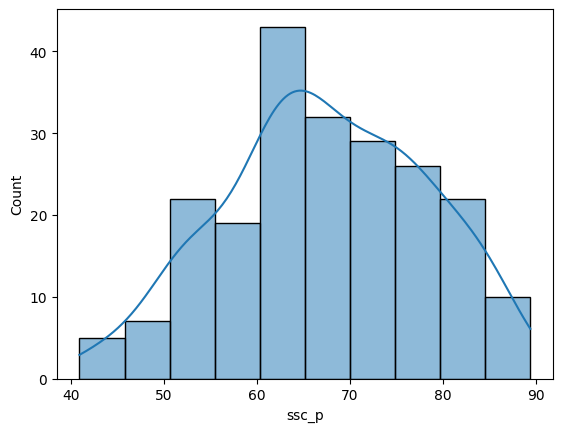

In [5]:
#sns.distplot(dataset["ssc_p"])-old method
sns.histplot(dataset["ssc_p"], kde=True)

In [6]:
#Probablity Density function = PDF
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    #sns.histplot(dataset, kde=True, kde_kws={'color':'blue'},color='Green')
    #kernel density function (kde) to get the curve
    sns.histplot(dataset, kde=True, color='green')
    #vline - vertical line
    plt.axvline(startrange,color='Red')
    plt.axvline(endrange,color='Red')
    #generate a sample
    sample = dataset
    #calculate parameters
    sample_mean = dataset.mean()
    sample_std = dataset.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    #define the distribution, #norm from scipy.stats import norm
    dist=norm(sample_mean, sample_std)
    #sample probablity for a range of outcomes
    values=[value for value in range(startrange,endrange)]
    #pdf is a function
    probabilities = [dist.pdf(value) for value in values]
    #summation
    prob=sum(probabilities)
    print("The area between range ({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

Mean=67.303, Standard Deviation=10.827
The area between range (40,50):0.04489259448345172


np.float64(0.04489259448345172)

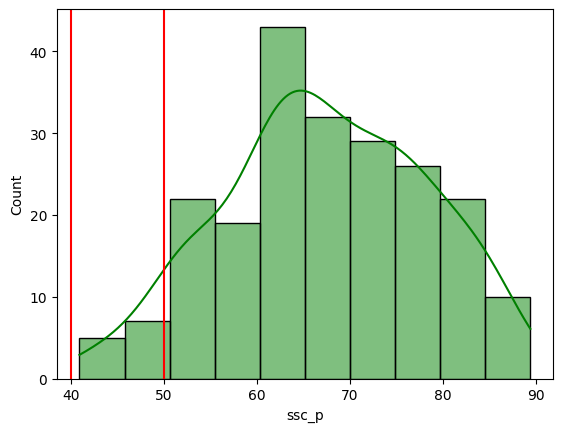

In [7]:
get_pdf_probability(dataset['ssc_p'],40,50)

In [10]:
#empirical cumulative density function ECDF
from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset['ssc_p'])
ecdf(78)

np.float64(0.827906976744186)

In [20]:
#standard normal distribution
def stdNDgraph(dataset):
    import seaborn as sns
    #import matplotlib.pyplot as plt
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_score=[((j - mean)/std)for j in values]
    sns.histplot(z_score,kde=True)
    return sum(z_score)/len(z_score)


np.float64(-4.2911410858767677e-16)

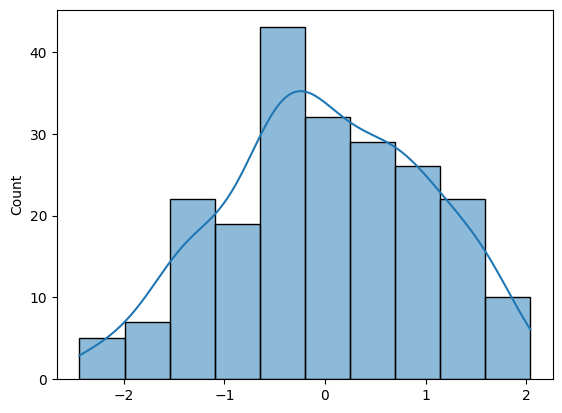

In [23]:
stdNDgraph(dataset['ssc_p'])